In [1]:
import pandas as pd
df= pd.read_csv("penguins_cleaned.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_mm_outlier,bill_depth_mm_outlier,flipper_length_mm_outlier,body_mass_g_outlier,is_any_outlier,body_mass_kg,bill_area_mm2,bill_ratio,flipper_mass_ratio
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,Male,False,False,False,False,False,3.75,731.170,2.090909,48.266667
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,Female,False,False,False,False,False,3.80,687.300,2.270115,48.947368
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,Female,False,False,False,False,False,3.25,725.400,2.238889,60.000000
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,Unknown,False,False,False,False,False,4.05,768.985,2.569364,48.641975
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,Female,False,False,False,False,False,3.45,708.310,1.901554,55.942029


In [2]:
# Select significant features
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[features]

# Standardize feature for clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Feature Selection

We selected the following features for clustering and dimensionality reduction:

- bill_length  
- bill_depth  
- flipper_length  
- body_mass  

These features represent key physical characteristics of penguins, capturing both size (body mass, flipper length) and morphology (bill dimensions). They are continuous and exhibit meaningful variation across species, making them suitable for distance-based algorithms such as K-Means.

Additionally, these features are biologically interpretable and allow us to distinguish between species based on measurable physical traits.

In [3]:
#Train Clustering (K-Means)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels

In [4]:
# Evaluation
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_scaled, labels)
print(sil_score)

0.44428701706572565


In [5]:
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['species'], labels)
print(ari)

0.7802764801745099


## Model Evaluation

We evaluate clustering performance using two metrics:

- Silhouette Score: measures how well-separated the clusters are
- Adjusted Rand Index (ARI): compares clustering results with true species labels

Results:

- Silhouette Score: 0.44428701706572565
- ARI Score: 0.7802764801745099


The Silhouette Score indicates a moderate level of separation between clusters. This suggests that while clusters are reasonably well-formed, there is still some overlap between them.

On the other hand, the ARI score is relatively high, indicating that the clustering aligns well with the true species labels.

This combination reveals an important insight: although the model successfully captures the underlying structure of the data, the boundaries between clusters are not perfectly distinct. In particular, some species share similar physical characteristics, leading to overlapping regions in feature space.



In [6]:
# Dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

In [7]:
pca.explained_variance_ratio_

array([0.68837221, 0.19313603])

<BarContainer object of 2 artists>

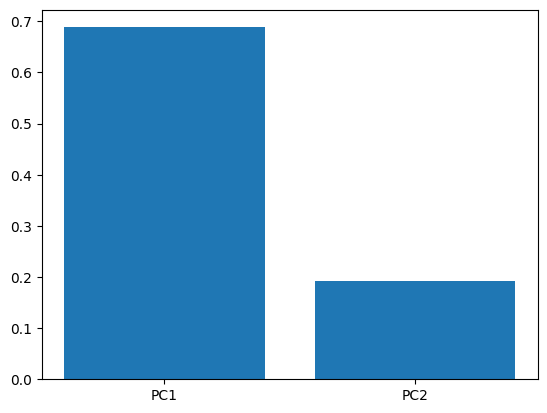

In [17]:
import matplotlib.pyplot as plt

plt.bar(['PC1', 'PC2'], pca.explained_variance_ratio_)

## PCA Explained Variance

The bar chart shows the proportion of variance explained by each principal component.

- PC1 explains approximately **69%** of the total variance.
- PC2 explains approximately **19%** of the total variance.

This means that the first two principal components together capture around **88% of the information** in the original dataset.

PC1 is the most important direction, representing the largest variation in penguin physical characteristics. It likely captures overall size-related features such as body mass and flipper length.

PC2 captures additional variation that is not explained by PC1, potentially reflecting differences in bill dimensions or shape.


In [13]:
def plot_pca_clusters(df, sil_score, ari_score):
    import plotly.express as px

    fig = px.scatter(
        df,
        x='PC1',
        y='PC2',
        color='cluster',
        hover_data=['species', 'island', 'sex'],
        title=f"PCA Clustering | Silhouette: {sil_score:.2f} | ARI: {ari_score:.2f}"
    )

    return fig
plot_pca_clusters(df, sil_score, ari)

In [20]:
df.groupby('cluster')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,38.208333,18.110606,188.401515,3584.659091
1,47.504878,14.982114,217.186992,5076.016260
2,47.456180,18.729213,196.898876,3905.337079


## Cluster Interpretation

To understand the structure of the clusters, we examine the average feature values within each cluster.

Each cluster is defined by distinct physical characteristics:

- One cluster is characterized by larger body mass and longer flippers, indicating larger penguins.
- Another cluster consists of smaller penguins with shorter flippers and lower body mass.
- The remaining cluster shows intermediate characteristics, particularly distinct in bill dimensions.

In terms of species separability:

- Gentoo penguins are cleanly separable, forming a distinct cluster due to their significantly larger size.
- Adelie and Chinstrap penguins exhibit overlap, as their physical characteristics are more similar.

In [16]:
def plot_pca_species(df):
    import plotly.express as px

    fig = px.scatter(
        df,
        x='PC1',
        y='PC2',
        color='species',
        title="Ground Truth (Species)"
    )

    return fig
plot_pca_species(df)

## Failure Analysis

The clustering model does not perfectly separate all species.

The main source of error lies in the overlap between Adelie and Chinstrap penguins. These two species share similar physical characteristics, particularly in bill size and body mass, making them difficult to distinguish using the selected features.

Additionally, K-Means assumes spherical cluster shapes and equal variance, which may not accurately reflect the true distribution of the data. This limitation contributes to misclassification in overlapping regions.

Therefore, while clustering performs well for clearly distinct species, it struggles in areas where feature distributions overlap.